# Load libraries 

In [11]:
import numpy as np  
import urllib.request
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import linregress
import pandas as pd 
import calplot
import seaborn as sns
from scipy.stats import gaussian_kde
import calplot
import plotly.express as px
import json
import math

# Load data

In [2]:
sf_crime_data = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/Data/Police_Incident_Reports_2003_2025_Cleaned.csv")

pd.set_option('display.max_columns', None)

/var/folders/h9/b0m54z_x70z3xs93z4k09jwc0000gn/T/ipykernel_58773/1023784767.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  sf_crime_data = pd.read_csv("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/Data/Police_Incident_Reports_2003_2025_Cleaned.csv")


In [4]:
len(sf_crime_data)

3015367

In [3]:
sf_crime_data.head()

,Incident Date,Incident Time,Incident Day of Week,Incident ID,Incident Number,Incident Code,Incident Category,Incident Description,Resolution,Police District,Analysis Neighborhood,Latitude,Longitude,Point
0,2023-03-01,05:02,Wednesday,1253795,236046151,6374,Larceny Theft,"theft, other property, >$950",open or active,mission,NaN,NaN,NaN,NaN
1,2023-03-13,10:59,Monday,1253551,230174885,7041,Recovered Vehicle,"vehicle, recovered, auto",open or active,out of sf,NaN,NaN,NaN,NaN
2,2023-03-14,18:44,Tuesday,1254024,230176728,7041,Recovered Vehicle,"vehicle, recovered, auto",open or active,out of sf,NaN,NaN,NaN,NaN
3,2023-02-15,03:00,Wednesday,1253786,236046123,6372,Larceny Theft,"theft, other property, $50-$200",open or active,mission,NaN,NaN,NaN,NaN
4,2023-03-13,11:26,Monday,1254195,236046850,6244,Larceny Theft,"theft, from locked vehicle, >$950",open or active,central,NaN,NaN,NaN,NaN


#### Format date and time 

In [3]:
sf_crime_data["Incident Date"] = pd.to_datetime(sf_crime_data["Incident Date"], format="%Y-%m-%d", errors="coerce")
sf_crime_data["Incident Hour"] = pd.to_datetime(sf_crime_data["Incident Time"], format="%H:%M", errors="coerce").dt.hour
sf_crime_data["Incident Time"] = pd.to_datetime(sf_crime_data["Incident Time"], format="%H:%M", errors="coerce").dt.time



In [4]:
sf_crime_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3015367 entries, 0 to 3015366
Data columns (total 15 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Incident Date          datetime64[ns]
 1   Incident Time          object        
 2   Incident Day of Week   object        
 3   Incident ID            int64         
 4   Incident Number        int64         
 5   Incident Code          int64         
 6   Incident Category      object        
 7   Incident Description   object        
 8   Resolution             object        
 9   Police District        object        
 10  Analysis Neighborhood  object        
 11  Latitude               float64       
 12  Longitude              float64       
 13  Point                  object        
 14  Incident Hour          int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(3), object(8)
memory usage: 333.6+ MB


## Part 1

From week 1's exercise, I'd like you to complete the "*Exercise 3*: Temporal patterns". The one where the main plot is the year-by-year evolution of the 10 focus crimes.

**IMPORTANT**: FOR THIS AND ALL SUBSEQUENT EXERCISES, I WANT YOU TO USE THE FULL DATASET FROM 2003 TO 2025.

The plot above already gives us a bit of information but does not tell us anything about how crimes changed over the years. Let's have a look at it!

> *Exercise 3*: Temporal patterns.
> * To start off easily, let's count the number of crimes per year:
>     * What is the year with most crimes? 
>     * What is the year with the fewest crimes?.
> * Create a barplot of crimes-per-year (years on the $x$-axis, crime-counts on the $y$-axis).
> * Finally, Police chief Suneman is interested in the temporal development of only a **subset of categories, the so-called *focus crimes***. Those categories are listed below (for convenient copy-paste action). Create bar-charts displaying the year-by-year development of each of these categories across the years 2003-2017.
> 

### 1.1 To start off easily, let's count the number of crimes per year:
- What is the year with most crimes? 
- What is the year with the fewest crimes?.

In [5]:
sf_crime_data["Year"] = sf_crime_data["Incident Date"].dt.year
crime_counts_per_year = sf_crime_data["Year"].value_counts().sort_index()

In [6]:
most_crimes_year = crime_counts_per_year.idxmax()  
fewest_crimes_year = crime_counts_per_year.idxmin()  

most_crimes_count = crime_counts_per_year.max()  
fewest_crimes_count = crime_counts_per_year.min()  

# print
print(crime_counts_per_year)
print(f"The year with the most crimes: {most_crimes_year} ({most_crimes_count} crimes)")
print(f"The year with the fewest crimes: {fewest_crimes_year} ({fewest_crimes_count} crimes)")

Year
2003    142803
2004    142054
2005    137048
2006    131856
2007    131771
2008    135242
2009    134309
2010    127758
2011    126713
2012    135464
2013    147664
2014    144844
2015    151459
2016    145994
2017    149487
2018    151581
2019    146715
2020    117504
2021    128349
2022    135667
2023    133077
2024    108445
2025      9563
Name: count, dtype: int64
The year with the most crimes: 2018 (151581 crimes)
The year with the fewest crimes: 2025 (9563 crimes)


### 1.2 Create a barplot of crimes-per-year (years on the $x$-axis, crime-counts on the $y$-axis)

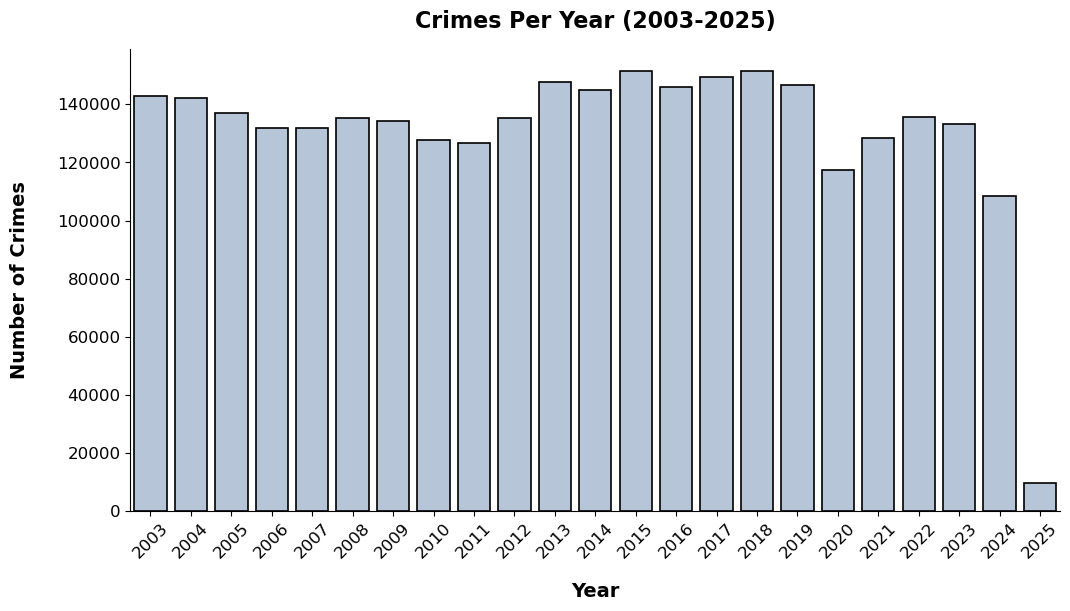

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(x=crime_counts_per_year.index, 
            y=crime_counts_per_year.values, 
            color="lightsteelblue",  # Lighter fill color
            edgecolor="black",       # Darker border color
            linewidth=1.2)           # Edge thickness for better contrast



# Plotting format
plt.xlabel("Year", fontsize=14, labelpad=15, fontweight="bold")
plt.ylabel("Number of Crimes", fontsize=14, labelpad=20, fontweight="bold")
plt.title("Crimes Per Year (2003-2025)", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)
plt.grid(False)
sns.despine(top=True, right=True)
plt.show()

### 1.3 Create bar-charts displaying the year-by-year development of each of these categories across the years 2003-2017. **IN THIS CASE 2003-2025**

In [8]:
sf_crime_data["Incident Category"] = sf_crime_data["Incident Category"].replace({
    "Weapons Carrying Etc": "Weapon Laws",
    "Weapons Offense": "Weapon Laws",
    "Weapons Offence": "Weapon Laws",
    "Drug Violation": "Drug/Narcotic",
    "Drug Offense": "Drug/Narcotic",
    "Motor Vehicle Theft": "Vehicle Theft",
    "Motor Vehicle Theft?": "Vehicle Theft",
    "Malicious Mischief": "Vandalism"
})

In [9]:
focuscrimes = set([
    "Weapon Laws", "Prostitution", "Robbery", "Burglary", "Assault",
    "Drug/Narcotic", "Larceny Theft", "Vandalism", "Vehicle Theft", "Stolen Property"
])
focus_crime_data = sf_crime_data[sf_crime_data["Incident Category"].isin(focuscrimes)]
crime_counts = focus_crime_data.groupby(["Incident Category", "Year"]).size().reset_index(name="Count")

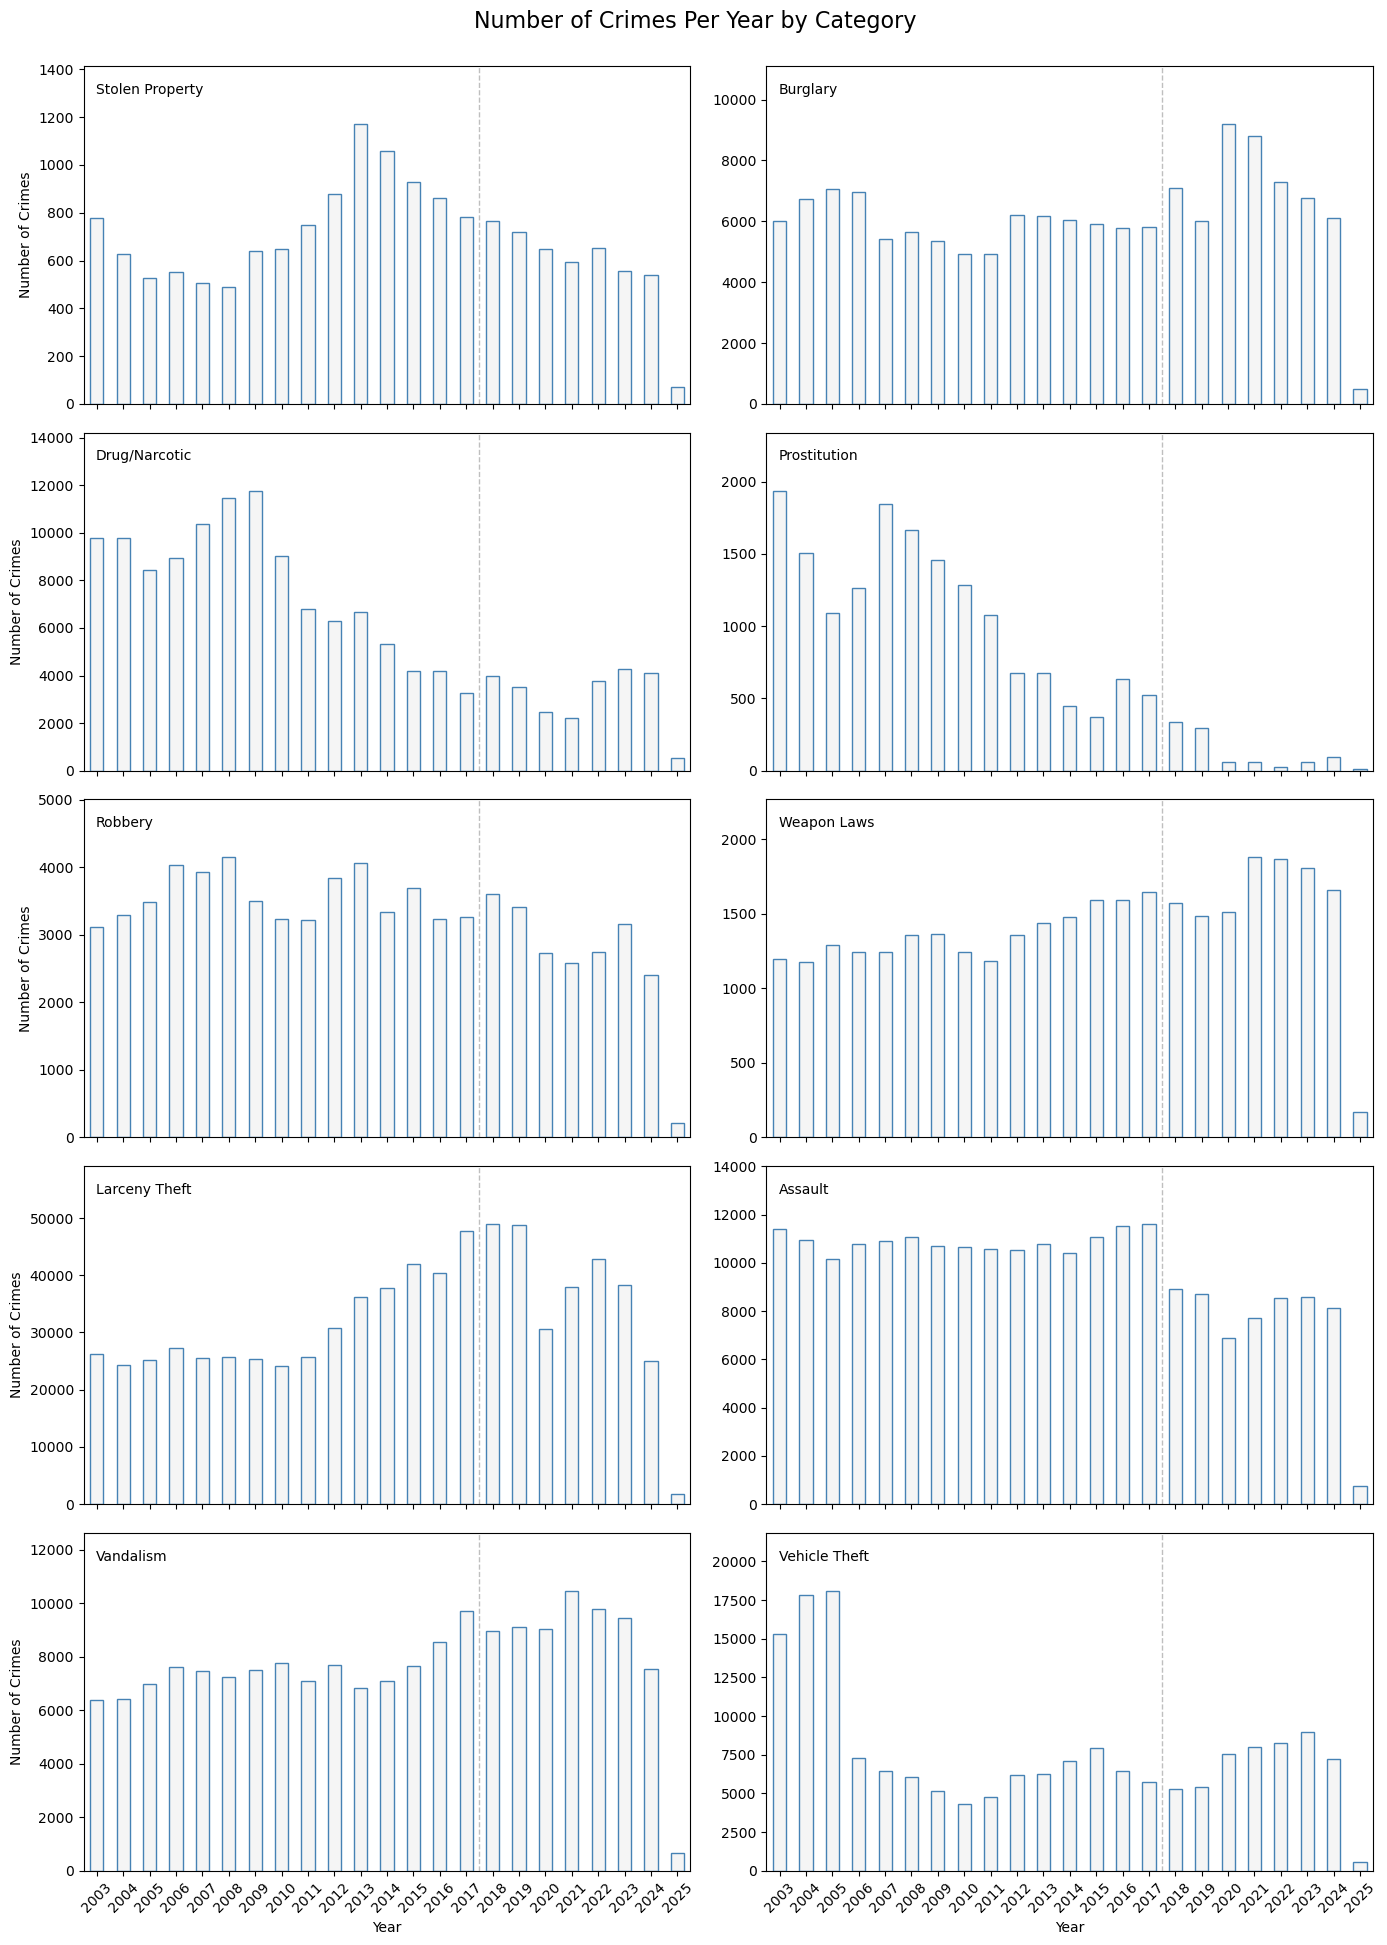

In [13]:
# Step 5: Calculate the number of rows needed for the subplots
num_crimes = len(focuscrimes)
cols = 2
rows = math.ceil(num_crimes / cols)

# Step 6: Create the subplots with the dynamic grid size
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(14, 4 * rows))  # Adjust figure size for dynamic layout
axes = axes.flatten()

# Loop through each crime category and create a bar plot
for i, crime in enumerate(focuscrimes):
    ax = axes[i]
    
    # Filter data for this specific crime category
    crime_data = crime_counts[crime_counts["Incident Category"] == crime]
    
    # Create bar plot with desired format
    sns.barplot(x="Year", y="Count", data=crime_data, color="whitesmoke", edgecolor="steelblue", width=0.5, ax=ax)

    # Adjust top margin dynamically for better label placement
    ax.set_ylim(0, ax.get_ylim()[1] * 1.15)

    # Add category label inside the plot (top-left corner)
    ax.text(
        0.02, 0.95,
        crime, fontsize=10, fontweight="normal", va="top", ha="left",
        transform=ax.transAxes
    )

    # Add a **light grey dashed separator line** at year 2017
    ax.axvline(x=14.5, color="grey", linestyle="--", linewidth=1, alpha=0.5)

    # Show y-axis label only for left-side subplots (column 1)
    if i % cols == 0:
        ax.set_ylabel("Number of Crimes", fontsize=10)
    else:
        ax.set_ylabel("")

    # Hide x-axis labels for all but the last row
    if i < len(focuscrimes) - cols:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xlabel("Year", fontsize=10)
        ax.tick_params(axis="x", rotation=45)

# Remove any empty subplots if categories are not evenly distributed
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a main title for the figure
fig.suptitle("Number of Crimes Per Year by Category", fontsize=16, y=1)

# Adjust layout for better spacing
plt.tight_layout(rect=[0, 0.03, 1, 1])  # Adjust spacing for **better fit**
plt.show()

## Part 2

Next, I would like you to answer some of the questions related to the videos shown during week 2. Specifically, I would like you to

* Answer questions related to the main video-lecture on Data Visualization. (Where the first question is "What is the difference between *data* and *metadata*?")
* Answer questions related to the video on "Nice plots". That is, generate the list of 10 rules for nice plots.


> *Excercise:* Questions for the lecture. 
> 
> * What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?
> * Sune says that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye](http://cdn.ebaumsworld.com/mediaFiles/picture/718392/84732652.jpg). Explain why your example is difficult. 
> * Simpson's paradox is hard to explain. Come up with your own example - or find one on line.
> * In your own words, explain the differnece between *exploratory* and *explanatory* data analysis.
>



### 2.1 What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?

*Metadata* is the data that is telling us something about the data we are working with. So it provides context and description of the raw data.

Where *Data* is the raw data/information collected. This could measuers, observations from various devices.  

For GPS tracks, metadata might include:
- Collection method: What device recorded the data from. Could be a phone or a computer
- Accuracy: How precise the location data is
- Timestamp format: The time zone used for recording

and then the data would then be: 
- the raw data colleced from the device
- the precision score it self
- the time for the given observation

### 2.2 Sune says that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye]

I agree that our eyes is really good for data analysis but at the same time we also need the descriptive statistics and numerical values as a dimension to undertand what is going on in a visiulizaiton. But in first glance our eyes gives a lot of great and fast information. I think our eyes becomes limited when working with darker environments, very dense areas and stuff that that is almost identical

### 2.3 Simpson's paradox is hard to explain. Come up with your own example - or find one online

The simpsons paradox is when you can draw different conclusions based on the way you divide the data up. 

So if cats and people get two different treatments - *Treatment A* and *Treatment B*, then  we can set it up: 

Cats:
- 90 out of 100 cats given Treatment A recovered (90%).
- 30 out of 50 cats given Treatment B recovered (60%).

People:
- 10 out of 100 people given Treatment A recovered (10%).
-	20 out of 50 people given Treatment B recovered (40%). 

So if we take a look at treatment A across people and cats, then we have 100/200, so 50% recover rate 
And Treatment B 50/100, so 50% recover rate as well. So by looking at that it looks like both treatments is equally good. 

Cats have much higher recovery rates overall, so if more cats receive Treatment A, it can inflate the apparent effectiveness of Treatment A when looking at the combined total, so if more people receive Treatment B, it can boost its overall percentage


Source: https://www.youtube.com/watch?v=ebEkn-BiW5k

## Part 3

We stay with week 2. I would also like you to complete the exercise in Week 2, Part 4, entitled "*Exercise*: Other cool ways to plot temporal data" (the one where we explore alternatives to bar-plots, such as calendar plots, for plotting temporal data).

In the exercise, i ask you to explore 3 different types of plots. For this assignment, you only need to do a calendar and polar bar chart.


### 3.1 Calender plot 

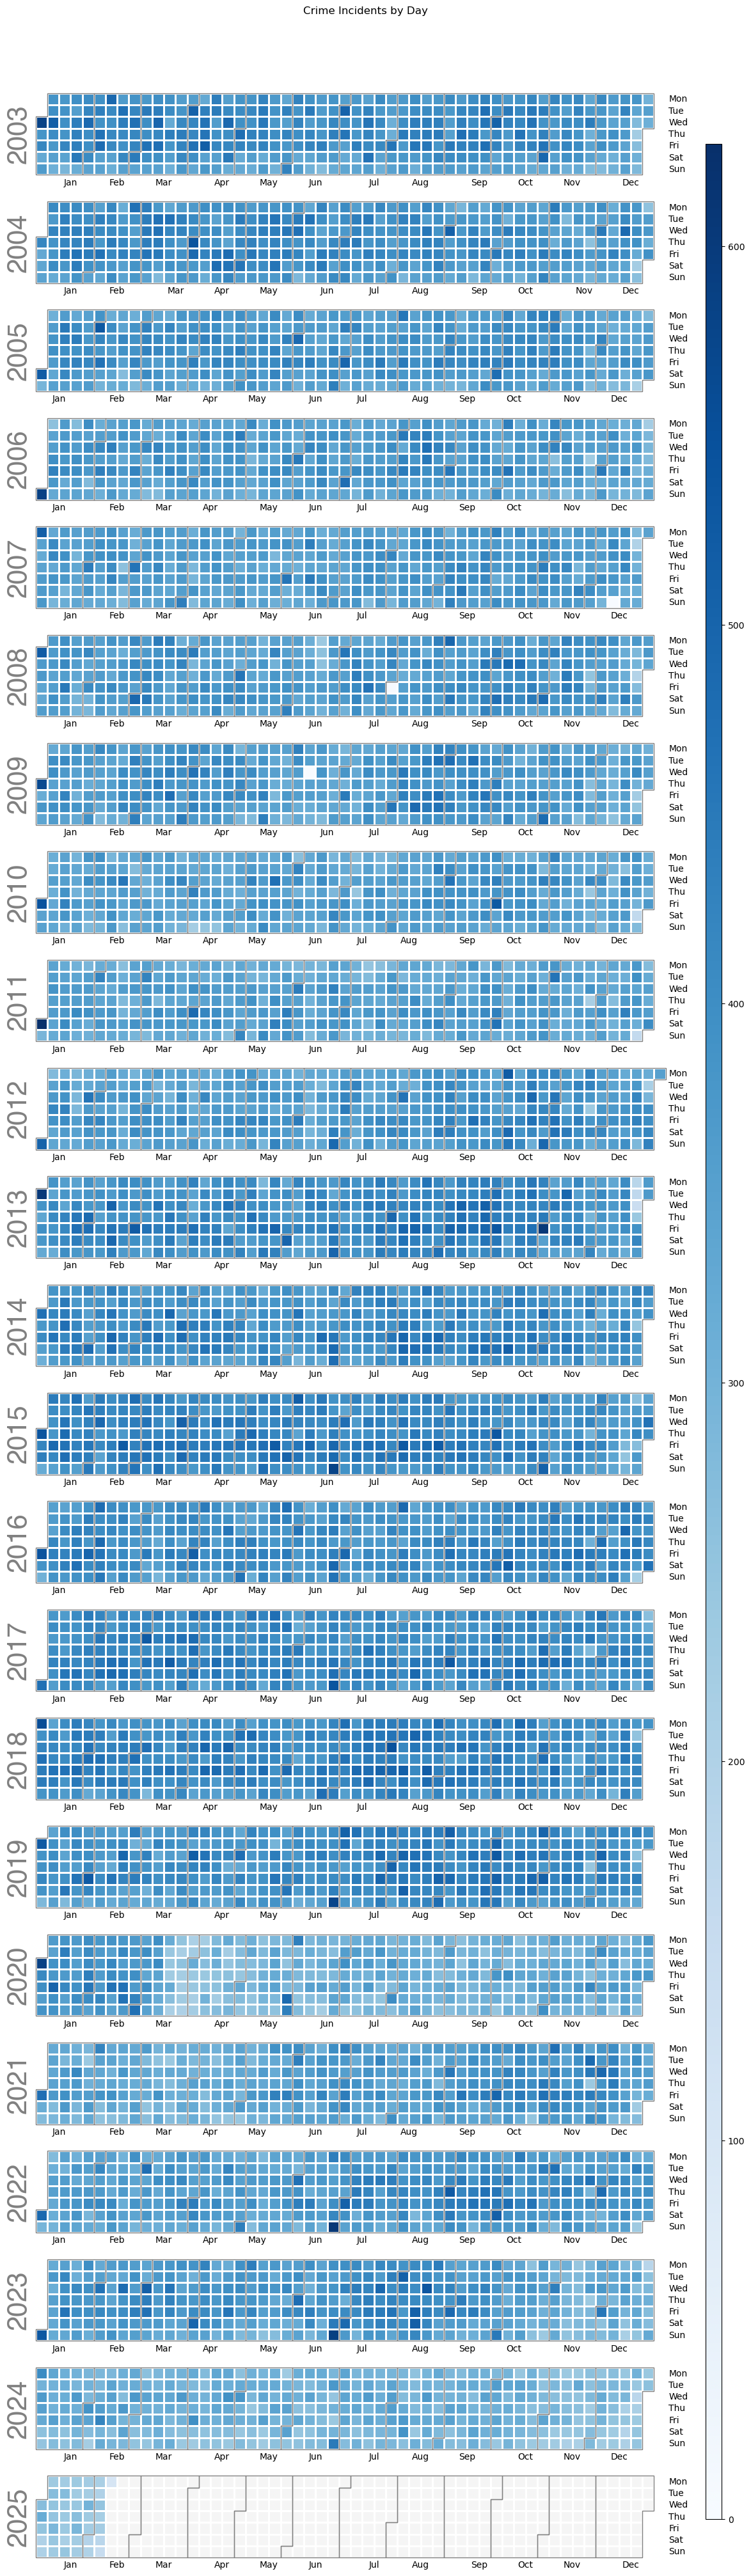

In [17]:
# Aggregate crime counts by date
crime_counts = sf_crime_data.groupby("Incident Date").size()

# Generate calendar heatmap
calplot.calplot(crime_counts, cmap="Blues", suptitle="Crime Incidents by Day", colorbar=True)

plt.show()

make comment on what it shows

### 3.2 Polar bar chart 

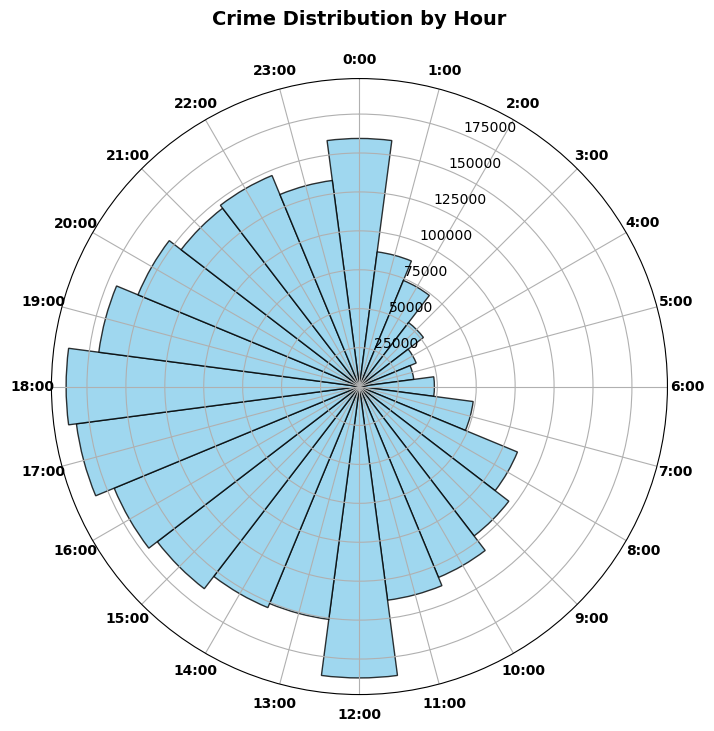

In [ ]:
# Count occurrences for each hour (0-23)
hourly_counts = sf_crime_data["Incident Hour"].value_counts().reindex(range(24), fill_value=0)

# Convert hour indices to radians for circular plotting
theta = np.linspace(0, 2*np.pi, 24, endpoint=False)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})

# Create polar bar chart with refined aesthetics
bars = ax.bar(theta, hourly_counts, width=np.pi/12, color="skyblue", edgecolor="black", alpha=0.8)

# Adjust x-ticks for better readability
ax.set_xticks(theta)
ax.set_xticklabels([f"{h}:00" for h in range(24)], fontsize=10, fontweight="bold")

# Enhance title and layout
ax.set_title("Crime Distribution by Hour", fontsize=14, fontweight="bold", pad=20)


ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

plt.show()

The plot shows that crime activity is often higher in the late afternoon and early evening, peaking between 17:00 and 19:00, with another noteworthy spike around midnight.  Early morning hours, particularly from 3:00 and 6:00, had much lower crime rates. Also to be noted is there is a peak around mid day. 

## Part 4

From week 3, I'd like you to work on the exercise contained in Week 3, Part 3. Specifically, I would like you to **both** complete "*Excercise Part 1*: Connecting the dots and recreating plots from DAOST but using our own favorite dataset" and "*Excercise Part 2*". These exercises focus on reproducing figure 2.1, 2.4 and 2.11 and exploring a few more ideas from the book using data from SFPD.


In [8]:
df_exercise1 = sf_crime_data
df_exercise2 = sf_crime_data

In [13]:
df_exercise1.head()

,Incident Date,Incident Time,Incident Day of Week,Incident ID,Incident Number,Incident Code,Incident Category,Incident Description,Resolution,Police District,Analysis Neighborhood,Latitude,Longitude,Point,Incident Hour
0,2023-03-01,05:02:00,Wednesday,1253795,236046151,6374,Larceny Theft,"theft, other property, >$950",open or active,mission,NaN,NaN,NaN,NaN,5
1,2023-03-13,10:59:00,Monday,1253551,230174885,7041,Recovered Vehicle,"vehicle, recovered, auto",open or active,out of sf,NaN,NaN,NaN,NaN,10
2,2023-03-14,18:44:00,Tuesday,1254024,230176728,7041,Recovered Vehicle,"vehicle, recovered, auto",open or active,out of sf,NaN,NaN,NaN,NaN,18
3,2023-02-15,03:00:00,Wednesday,1253786,236046123,6372,Larceny Theft,"theft, other property, $50-$200",open or active,mission,NaN,NaN,NaN,NaN,3
4,2023-03-13,11:26:00,Monday,1254195,236046850,6244,Larceny Theft,"theft, from locked vehicle, >$950",open or active,central,NaN,NaN,NaN,NaN,11


### 4.1 Excercise part 1: Connecting the dots and recreating plots from DAOST but using our own favorite dataset.

#### 4.1.1 Let's make a jitter-plot (that is, code up something like **Figure 2-1** from DAOST from scratch)

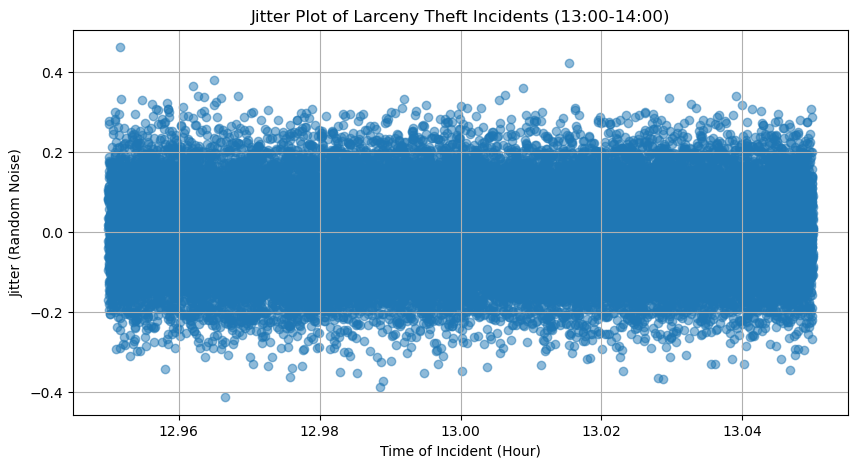

In [ ]:
crime_type = "Larceny Theft"
df_filtered = df_exercise1[df_exercise1["Incident Category"] == crime_type].copy()

# Use the preformatted "Incident Hour" column instead of reformatting "Incident Time"
df_filtered = df_filtered.dropna(subset=["Incident Hour"])  # Ensure valid numeric values

# Focus on incidents between 13:00 and 14:00
df_hour = df_filtered[(df_filtered["Incident Hour"] >= 13) & (df_filtered["Incident Hour"] < 14)].copy()

# Ensure we have data before plotting
if df_hour.empty:
    print("No data found for Larceny Theft incidents between 13:00-14:00.")
else:
    # Add jitter for better visibility
    df_hour["Jitter"] = np.random.normal(0, 0.1, size=len(df_hour))

    # Create jitter plot
    plt.figure(figsize=(10, 5))
    plt.scatter(df_hour["Incident Hour"] + np.random.uniform(-0.05, 0.05, len(df_hour)), df_hour["Jitter"], alpha=0.5)
    plt.xlabel("Time of Incident (Hour)")
    plt.ylabel("Jitter (Random Noise)")
    plt.title(f"Jitter Plot of {crime_type} Incidents (13:00-14:00)")
    plt.grid(True)
    plt.show()

<span style="color:lightblue; font-weight:bold;"> Comments:</span>

- There is no strong clustering at specific sub-hour times, indicating that incidents occur fairly evenly within this period.

- The uniform spread implies that no particular sub-interval (e.g., 13:15 or 13:30) dominates in theft frequency during this hour.

#### 4.1.2 creating two crime-data based versions of the plot-type shown in DAOST **Figure 2-2**

Burglary count: 5852
Larceny Theft count: 21765


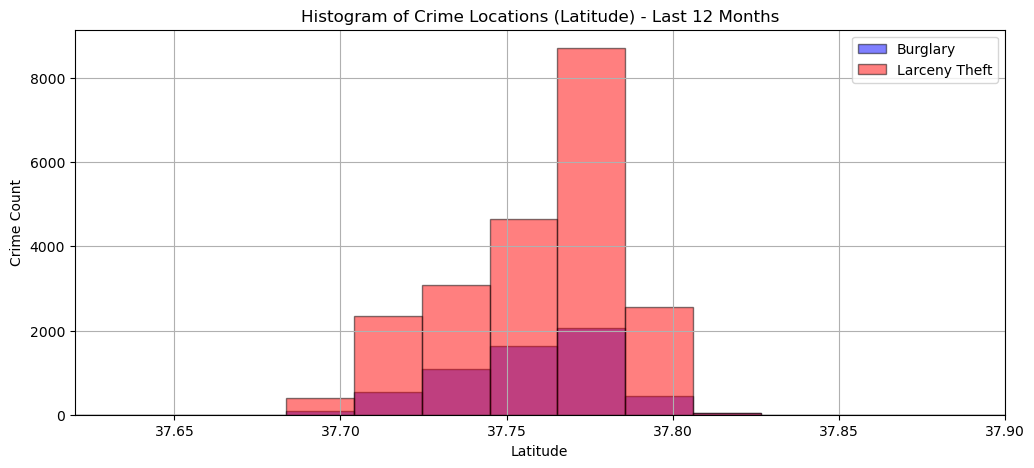

In [16]:

# Choose two crime types with different geographic patterns
crime1 = "Burglary"
crime2 = "Larceny Theft"

# Select a suitable time range 
recent_date = df_exercise1["Incident Date"].max()  # Get the latest date in the dataset
time_filter = df_exercise1["Incident Date"] >= (recent_date - pd.DateOffset(months=12))

# Apply time filter and crime filter
df_crime1 = df_exercise1[(df_exercise1["Incident Category"] == crime1) & time_filter]
df_crime2 = df_exercise1[(df_exercise1["Incident Category"] == crime2) & time_filter]

# Drop missing or invalid latitudes (San Francisco latitudes should be ~37-38)
df_crime1 = df_crime1[(df_crime1["Latitude"] > 37) & (df_crime1["Latitude"] < 38)]
df_crime2 = df_crime2[(df_crime2["Latitude"] > 37) & (df_crime2["Latitude"] < 38)]

# Print data count to ensure between 1000-10000
print(f"Burglary count: {len(df_crime1)}")
print(f"Larceny Theft count: {len(df_crime2)}")

# Define bin edges for latitude (50 bins)
bins = np.linspace(37, 38, 50)

# Compute histogram counts using numpy.histogram
hist_crime1, _ = np.histogram(df_crime1["Latitude"], bins=bins)
hist_crime2, _ = np.histogram(df_crime2["Latitude"], bins=bins)

# Plot histograms manually
plt.figure(figsize=(12, 5))
plt.bar(bins[:-1], hist_crime1, width=np.diff(bins)[0], alpha=0.5, label=crime1, color='blue', edgecolor="black")
plt.bar(bins[:-1], hist_crime2, width=np.diff(bins)[0], alpha=0.5, label=crime2, color='red', edgecolor="black")
plt.xlabel("Latitude")
plt.ylabel("Crime Count")
plt.title("Histogram of Crime Locations (Latitude) - Last 12 Months")
plt.legend()
plt.grid(True)
plt.xlim(37.62, 37.9)  # Zoom in on the relevant latitude range
plt.show()

write comment to plot. Not sure if this plot is correct. Please check if i have done it correct. 

#### 4.1.3 Next up is using the plot-type shown in **Figure 2-4** from DAOST - Kernel density plot

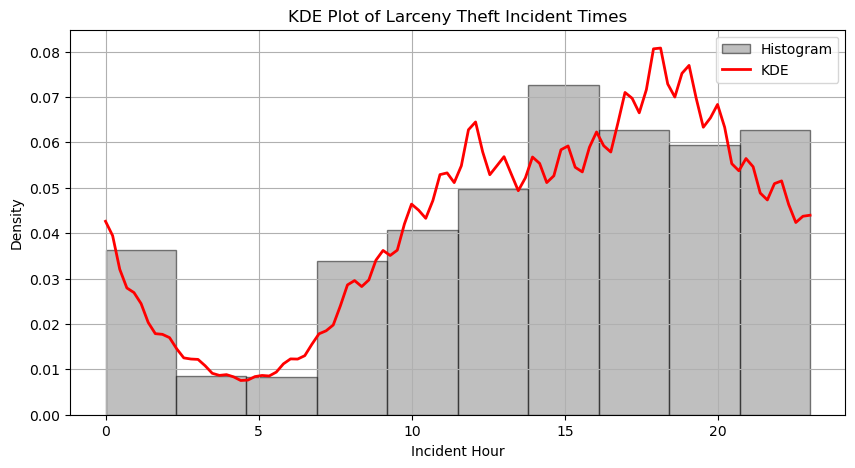

In [19]:
crime_type = "Larceny Theft"
df_filtered = df_exercise1[df_exercise1["Incident Category"] == crime_type]["Incident Hour"].dropna()

# Ensure "Incident Hour" is treated as numeric
df_filtered = df_filtered.astype(float)  

# Ensure there's enough data
if len(df_filtered) < 10:
    print("Not enough data for KDE plot")
else:
    # Compute KDE
    kde = gaussian_kde(df_filtered)
    x_vals = np.linspace(df_filtered.min(), df_filtered.max(), 100)
    y_vals = kde(x_vals)

    # Plot KDE and histogram
    plt.figure(figsize=(10, 5))
    plt.hist(df_filtered, bins=10, density=True, alpha=0.5, color="gray", label="Histogram", edgecolor="black")
    plt.plot(x_vals, y_vals, color="red", label="KDE", linewidth=2)
    plt.xlabel("Incident Hour")
    plt.ylabel("Density")
    plt.title(f"KDE Plot of {crime_type} Incident Times")
    plt.legend()
    plt.grid(True)
    plt.show()

<span style="color:lightblue; font-weight:bold;"> Comments:</span>

- Crime activity is lowest between 3 AM - 6 AM, likely due to fewer people being active during those hours. There is a gradual increase in incidents starting from the morning (around 8 AM), with a noticeable peak between 12 PM - 8 PM.

- The highest crime density occurs in the late afternoon and early evening (around 6 PM - 8 PM), which could correspond to increased foot traffic, shopping hours, or end-of-workday activities. 

- After 8 PM, incidents start to decline, though there remains a moderate level of crime activity late at night (10 PM - 12 AM).

_The overall pattern suggests that Larceny Theft incidents align with periods of high human activity, supporting the idea that theft is an opportunistic crime._

### 4.2 Excercise part 2: These exercises focus on reproducing figure 2.1, 2.4 and 2.11 and exploring a few more ideas from the book using data from SFPD.

#### 4.2.1  Now we'll work on creating two versions of the plot in **Figure 2-11**, but using the GPS data you used for your version of Figure 2-2. Comment on the result. It is not easy to create this plot from scracth.  

In [20]:
annita_df = sf_crime_data.copy() 

In [21]:
print(f"Missing Latitude values: {annita_df['Latitude'].isna().sum()}")
latitude_data = annita_df["Latitude"].dropna()

Missing Latitude values: 51053


Reproducing figure 2.11

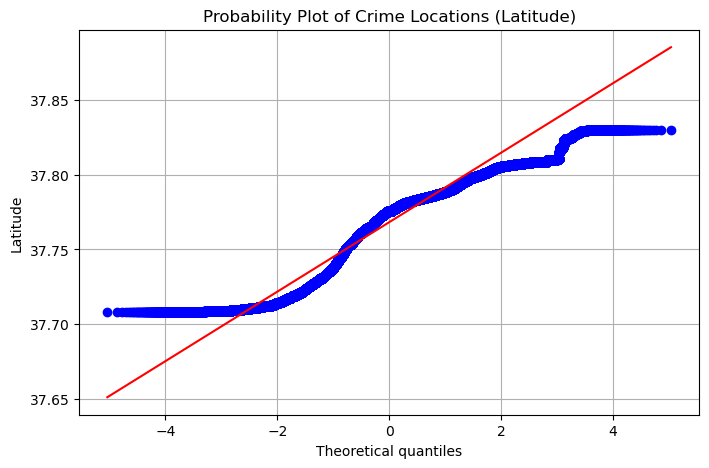

In [22]:
latitude_data_clean = latitude_data[(latitude_data > 37) & (latitude_data < 38)]

plt.figure(figsize=(8, 5))
stats.probplot(latitude_data_clean, dist="norm", plot=plt)

plt.title("Probability Plot of Crime Locations (Latitude)")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

<span style="color:lightblue; font-weight:bold;"> Comments:</span>

- Latitude values are not normally distributed, because if the data were normally distributed, the points would closely follow the red diagonal line. Here, the points deviate significantly, especially at the ends, confirming that crime locations are clustered rather than randomly distributed.

- The flat sections in the lower (-4) and upper (+4) quantiles suggest that some latitude values are more frequent than others.
This could indicate that crimes occur mostly in certain neighborhoods rather than being evenly spread across San Francisco.


Reproducing figure 2.1

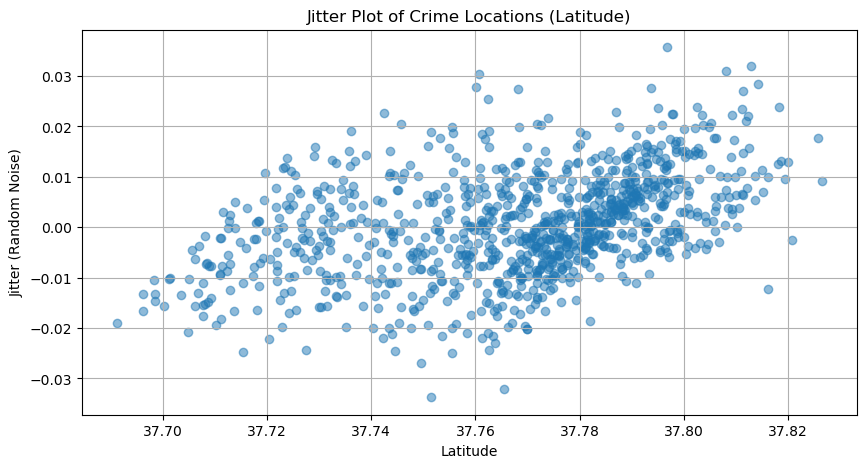

In [23]:
df_sample = annita_df.sample(1000)  # Use a smaller subset for clarity
df_sample["Jitter"] = np.random.normal(0, 0.01, size=len(df_sample))

# Plot
plt.figure(figsize=(10, 5))
plt.scatter(df_sample["Latitude"] + df_sample["Jitter"], df_sample["Jitter"], alpha=0.5)
plt.xlabel("Latitude")
plt.ylabel("Jitter (Random Noise)")
plt.title("Jitter Plot of Crime Locations (Latitude)")
plt.grid(True)
plt.show()

<span style="color:lightblue; font-weight:bold;"> Comments:</span>

- The highest density of points is between 37.75 and 37.80° latitude, suggesting crime is concentrated in certain areas rather than evenly distributed.

- The distribution widens slightly as latitude increases, meaning that higher-latitude crime locations are more spread out.

- Fewer points are observed in the lower latitude range, indicating less crime activity in these areas. This may be due to fewer populated zones or different land use patterns (parks, industrial areas, etc.).

#### 4.2.2 We need some box plots. Here, I'd like you to use the box plots to visualize fluctuations of how many crimes happen per day. We'll use data from the 15 focus crimes defined last week

#### 4.2.2.1 For the full time-span of the data, calulate the **number of crimes per day** within each category for the entire duration of the data.

#### 4.2.2.2 Create a box-and whiskers plot showing the mean, median, quantiles, etc for all 15 crime-types side-by-side
- What does this plot reveal that you can't see in the plots from last time?

### 4.2.3 Another interesting use of box plots

## Part 5

Finally, I'd like you to work on the exercise "*Exercise*: Using all the tools to understand the temporal trends of prostitution in SF over time" in Week 4, Part 3. 

# Part 3: Putting everything you've learned to work

Now you've learned about lots of time-series analysis tricks and visualization. That means it's time for you to think for yourself with a slightly more independent exercise.

> *Exercise*: Using all the tools to understand the temporal trends of prostitution in SF over time.
> * It's quite simple really, I'd like you to present your own analysis of what happens to the `PROSTITUTION`
> crime type in SF over time.
>   - Hint 1: So think about trends over time, does every district show the same behavior?, or the same beahavior over time?, are there hotspots?, etc. A fancy way of saying this is: think about quantifying and explaining spatio-temporal patterns.
>   - Hint 2: It's a good idea to think of this exercise as a way to show off what you've learned about data analysis in this and the previous lectures: so it's a good idea to include many of the types of plots from the curriculum so far in your analysis.
> * As an extra little thing, I also want you to reflect on the *role of data errors* in an analysis. Data errors could be things like imprecise GPS points, or imprecise recording of time.


#### Loading data 

In [49]:
sf_prostitution_df = sf_crime_data

with open("/Users/Thomas/Desktop/Skole/Business Analytics/Social data analysis and visualization/Data/sfpd.geojson") as f:
    geojson_data = json.load(f)

##### Formatting 

In [51]:
sf_prostitution_df['Incident Date'] = pd.to_datetime(sf_prostitution_df['Incident Date'])
sf_prostitution_df["Year"] = sf_prostitution_df["Incident Date"].dt.year

sf_prostitution_df['Incident Category'] = sf_prostitution_df['Incident Category'].str.upper()
sf_prostitution_df['Police District'] = sf_prostitution_df['Police District'].str.upper()


sf_prostitution_df = sf_prostitution_df[sf_prostitution_df['Police District'] != "OUT OF SF"]

#### In these analysis we will limit it to the past 10 years, so including 2025 data

#### First we will try take a "high level" look at data

##### First we create a line chart to see trend

Max Monthly Crime Count: 13463
Total Sum of Monthly Crimes: 1348313


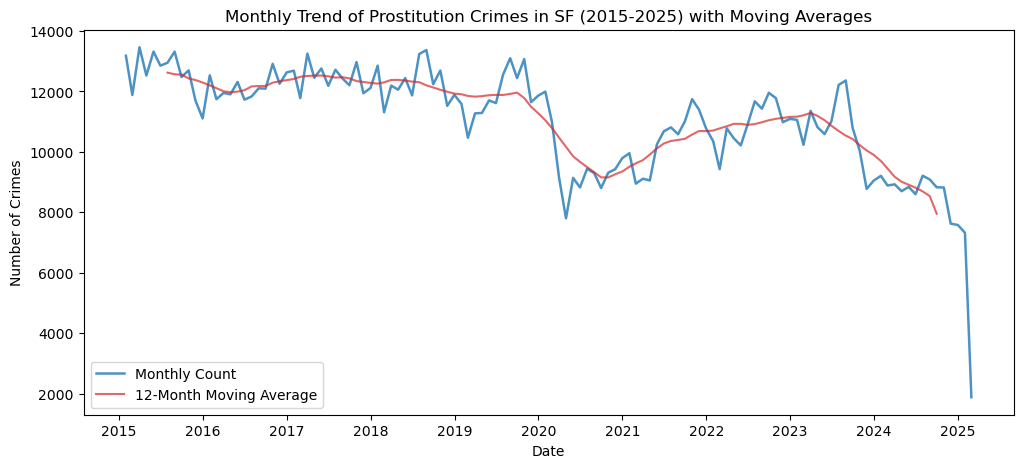

In [52]:
# Filter for the last 10 years (2015-2025)
recent_df = sf_prostitution_df[sf_prostitution_df['Year'] >= 2015]

# Aggregate by month
monthly_trend = recent_df.resample('ME', on='Incident Date').size()

# Apply Moving Averages
smoothed_trend_6 = monthly_trend.rolling(window=12, center=True).mean()  # 12-month moving average

# Debugging (optional)
print("Max Monthly Crime Count:", monthly_trend.max())
print("Total Sum of Monthly Crimes:", monthly_trend.sum())

# Plot both raw data and moving averages
plt.figure(figsize=(12, 5))

# Strong navy blue for Monthly Count
sns.lineplot(x=monthly_trend.index, y=monthly_trend.values, linewidth=1.8, color='#1f77b4', alpha=0.8, label="Monthly Count")

# Bold red for 12-month moving average
sns.lineplot(x=smoothed_trend_6.index, y=smoothed_trend_6.values, linewidth=1.5, color='#d62728', alpha=0.7, label="12-Month Moving Average")

# Formatting
plt.title("Monthly Trend of Prostitution Crimes in SF (2015-2025) with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")

# Ensure 2015 and 2025 appear on the x-axis
years = pd.date_range(start='2015-01-01', end='2025-12-31', freq='YS')  # Year start
plt.xticks(years, labels=[year.year for year in years])

plt.legend()
plt.show()

In general we see a lot of fluctuation in the crime counts. In general we see a downwards trend from 2015 to 2020 whereas it steadies out. 

But lets take a deep dive into interesting years:
- We see a steep drop in start 2020, this fits well with that SF close down due to covid (https://www.sf.gov/news--sf-responds-coronavirus-outbreak-stay-home-order)
- Then in start - around March 2021 we see an spike in increase of crimes in prostitution, this might be due to SF opens more up moving to "orange tier" meaning that business and activities to re-opens (https://www.huschblackwell.com/california-state-by-state-covid-19-guidance)
- If looking at another peak in crime in 2023, we see in start 2023 we see a sudden rise in crime again, this time San Fransico opens up and ends covid-19 health emergency (https://www.sf.gov/news--san-francisco-end-covid-19-public-health-emergency-declaration-and-health-orders)

So to conclude, we can see a fall over time in prostitution crimes, where the catalyst happens in 2020 where drops due to covid restrictions and increase/peaks in crimes happens when society partially or fully opens up again. At last we see after the drop in 2020 there is a upward trending where the it drops again in the end of 2023.  

##### Map of SF to see district with the most crimes

In [53]:
district_crime_counts = sf_prostitution_df.groupby("Police District").size().reset_index()
district_crime_counts.columns = ["DISTRICT", "CRIME_COUNT"]  

fig = px.choropleth_mapbox(
    district_crime_counts,
    geojson=geojson_data,
    locations="DISTRICT",  # Match with crime dataset
    featureidkey="properties.DISTRICT",  # Match with GeoJSON
    color="CRIME_COUNT",
    color_continuous_scale="Reds",  # Red = High crime, Light = Low crime
    range_color=[district_crime_counts["CRIME_COUNT"].min(), district_crime_counts["CRIME_COUNT"].max()],
    mapbox_style="carto-positron",
    zoom=10.7,  # SF city-wide view
    center={"lat": 37.7749, "lon": -122.4194},  # Centered on SF
    opacity=0.6,
    labels={"CRIME_COUNT": "Prostitution Crimes"}
)

# Improve layout
fig.update_layout(
    title_text="Total Prostitution Crimes in SF by District",
    margin={"r": 0, "t": 40, "l": 0, "b": 0},
    width=800  # Adjust width if needed
)

# Show the map
fig.show()

The plot shows the accumulated crimes for prostitution. Where the SOUTHERN district has had the most crimes over time. Second and third is NORTHEN and MISSION. 

##### Trend over time pr. district - A dig deeper down 

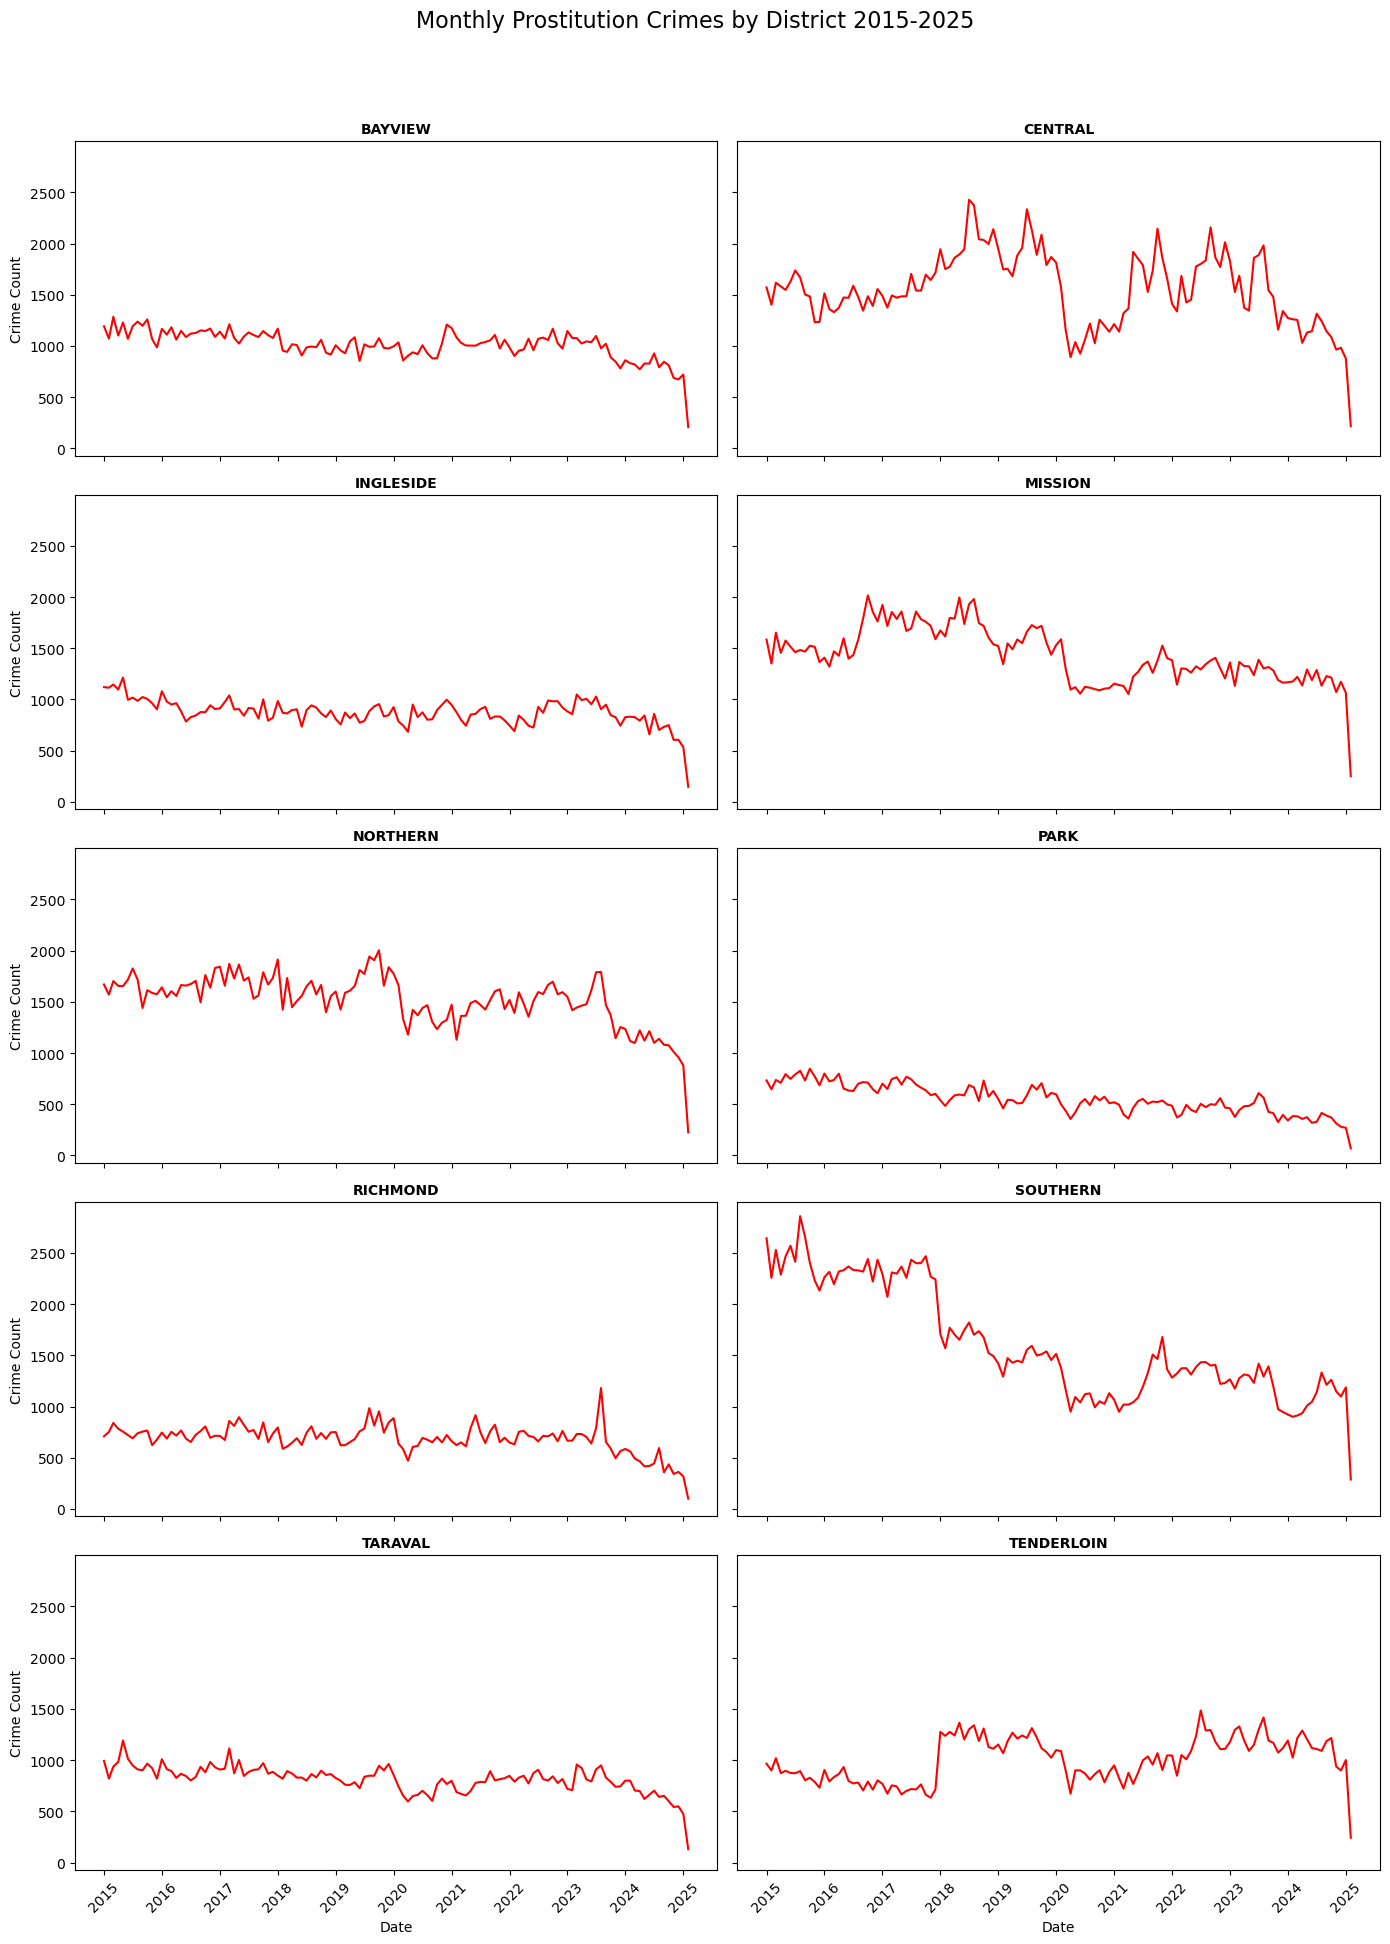

In [62]:

sf_prostitution_df = sf_prostitution_df.copy()
sf_prostitution_df["Incident Date"] = pd.to_datetime(sf_prostitution_df["Incident Date"])




# Determine date range dynamically
latest_date = sf_prostitution_df["Incident Date"].max()  # Last observed date
earliest_date = pd.Timestamp("2015-01-01")  # Start of analysis period

#  Generate all months between 2015 and the latest date
months = pd.date_range(start=earliest_date, end=latest_date, freq="MS")
months_df = pd.DataFrame({"Incident Date": months})

# Aggregate prostitution crimes per month and district
district_monthly_trends = sf_prostitution_df.groupby(
    [sf_prostitution_df["Incident Date"].dt.to_period("M"), "Police District"]
).size().reset_index()
district_monthly_trends.columns = ["Incident Date", "District", "Crime Count"]

# Convert Period to Timestamp to avoid FutureWarnings
district_monthly_trends["Incident Date"] = district_monthly_trends["Incident Date"].astype(str)
district_monthly_trends["Incident Date"] = pd.to_datetime(district_monthly_trends["Incident Date"])

# Ensure all months are represented across districts
districts = district_monthly_trends["District"].unique()
full_df = pd.concat([months_df.assign(District=d) for d in districts], ignore_index=True)

# Merge to maintain zero counts for missing months
district_monthly_trends = full_df.merge(district_monthly_trends, on=["Incident Date", "District"], how="left").fillna(0)

# Restrict the dataset to the observed time range
district_monthly_trends = district_monthly_trends[
    (district_monthly_trends["Incident Date"] >= earliest_date) &
    (district_monthly_trends["Incident Date"] <= latest_date)
]

# Define layout for subplots
num_districts = len(districts)
ncols, nrows = 2, (num_districts + 1) // 2
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows), sharex=True, sharey=True)
axes = axes.flatten()

#Plot trends for each district
for i, district in enumerate(districts):
    ax = axes[i]
    district_data = district_monthly_trends[district_monthly_trends["District"] == district]
    sns.lineplot(data=district_data, x="Incident Date", y="Crime Count", color="red", linewidth=1.5, ax=ax)
    
    ax.set_title(district, fontsize=10, fontweight="bold")
    ax.set_xlabel("Date", fontsize=10)
    ax.set_ylabel("Crime Count", fontsize=10)

    # Set x-axis ticks to ensure 2015 and latest year are visible
    ax.set_xticks(pd.date_range(start=earliest_date, end=latest_date, freq="YS"))
    ax.set_xticklabels([str(year) for year in range(2015, latest_date.year + 1)], rotation=45)

# Step 9: Remove extra empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Step 10: Adjust layout for readability
fig.suptitle(f"Monthly Prostitution Crimes by District 2015-{latest_date.year}", fontsize=16, y=1)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Prostitution crimes in the Southern District have decreased significantly between 2015 and the end of 2024, with notably sharp declines occurring in various phases.  By the end of 2024, its crime rate is closing in of some of the district, which has continually decreased and remained somehow stable throughout the years such as MISSION. 

So this helps us understand a trend rather that a "static" plot of the heatmap, that would just tell that SOUTRHN district would be the worst

# Contribution

In [1]:
contribution_dict = {
  "Student:s200513": "Write here",
  "Student:x": "Write here",
  "student:x": "Write here",
}

In [3]:
for student, contribution in contribution_dict.items():
  print(f"{student}: {contribution}")

Student:s200513: Write here
Student:x: Write here
student:x: Write here
